# Model Training Pipeline

## Loading the dataset

In [1]:
import glob
from typing import Tuple
import polars as pl
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
sns.set_theme(style="darkgrid", context="poster", palette="bright")
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 24,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14
})

In [3]:
PROJECT_ROOT = os.path.abspath("..")
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
MODEL_DIR = os.path.join(PROJECT_ROOT, "models")
ARTIFACT_DIR = os.path.join(PROJECT_ROOT, "artifacts")

In [4]:
def get_labels_from_filename(filename: str) -> Tuple[str, str, bool]:
    if "Benign" in filename:
        return "Benign", "Benign", False

    if "ARP_Spoofing" in filename:
        return "ARP_Spoofing", "Spoofing", True

    if "Recon" in filename:
        category = "Recon"
        if "Recon-Ping_Sweep" in filename:
            return "Ping_Sweep", category, True
        if "Recon-VulScan" in filename:
            return "VulScan", category, True
        if "Recon-OS_Scan" in filename:
            return "OS_Scan", category, True
        if "Recon-Port_Scan" in filename:
            return "Port_Scan", category, True

    if "MQTT" in filename:
        category = "MQTT"
        if "MQTT-Malformed_Data" in filename:
            return "Malformed_Data", category, True
        if "MQTT-DoS-Connect_Flood" in filename:
            return "DoS_Connect_Flood", category, True
        if "MQTT-DDoS-Publish_Flood" in filename:
            return "DDoS_Publish_Flood", category, True
        if "MQTT-DoS-Publish_Flood" in filename:
            return "DoS_Publish Flood", category, True
        if "MQTT-DDoS-Connect_Flood" in filename:
            return "DDoS_Connect_Flood", category, True

    if "TCP_IP-DoS" in filename:
        category = "DoS"
        if "TCP_IP-DoS-TCP" in filename:
            return "DoS_TCP", category, True
        if "TCP_IP-DoS-ICMP" in filename:
            return "DoS_ICMP", category, True
        if "TCP_IP-DoS-SYN" in filename:
            return "DoS_SYN", category, True
        if "TCP_IP-DoS-UDP" in filename:
            return "DoS_UDP", category, True

    if "TCP_IP-DDoS" in filename:
        category = "DDoS"
        if "TCP_IP-DDoS-SYN" in filename:
            return "DDoS_SYN", category, True
        if "TCP_IP-DDoS-TCP" in filename:
            return "DDoS_TCP", category, True
        if "TCP_IP-DDoS-ICMP" in filename:
            return "DDoS_ICMP", category, True
        if "TCP_IP-DDoS-UDP" in filename:
            return "DDoS_UDP", category, True

    return "", "", False

In [5]:
def combine_dataset_files(root: str, save_name: str = "combined_dataset") -> None:
    path = os.path.join(root, "*", "*.csv")
    files = glob.glob(path, recursive=True)
    combined_dir = os.path.join(root, "combined")
    out_path = os.path.join(combined_dir, f"{save_name}.parquet")
    os.makedirs(combined_dir, exist_ok=True)

    frames = []
    with pl.StringCache():
        for file in files:
            name, category, attack = get_labels_from_filename(file)

            lf = pl.scan_csv(file)

            lf = lf.with_columns(
                [
                    pl.lit(name).alias("Name").cast(pl.Categorical),
                    pl.lit(category).alias("Category").cast(pl.Categorical),
                    pl.lit(attack).alias("Attack"),
                ]
            )

            frames.append(lf)

        combined_lf = pl.concat(frames)
        combined_lf.sink_parquet(out_path)

In [6]:
def load_dataset(save_name: str) -> pl.DataFrame:
    path = os.path.join(DATA_DIR, "combined", f"{save_name}.parquet")
    if not os.path.exists(path):
        combine_dataset_files(DATA_DIR, save_name)
    df = pl.read_parquet(path)
    return df

In [7]:
df = load_dataset("combined_dataset").with_columns(
    pl.col(pl.Float64).cast(pl.Float32)
)  # reducing memory usage

## Preprocessing

In [8]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, BatchNormalization, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.metrics import F1Score
from sklearn.utils import class_weight

2026-03-14 13:51:18.215514: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-14 13:51:18.263120: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-14 13:51:19.689743: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [9]:
df = df.to_pandas()
df = df[df["Category"] != "Spoofing"].copy()  # Discarding spoofing data
df = df.reset_index(drop=True)
X = df.drop(columns=["Name", "Attack", "Category"])
y = df["Category"]
del df

### Splitting Data into Subsets

In [10]:
train_percent = 0.8
val_percent = 0.1
test_percent = 0.1

In [11]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=test_percent, random_state=42, stratify=y
)

val_adjusted_size = val_percent / (train_percent + val_percent)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=val_adjusted_size,
    random_state=42,
    stratify=y_train_val,
)

In [12]:
del X_train_val, y_train_val

In [13]:
print(f"Train {len(X_train)/len(X):.0%} ({len(X_train)} rows)")
print(f"Validation {len(X_val)/len(X):.0%} ({len(X_val)} rows)")
print(f"Test {len(X_test)/len(X):.0%} ({len(X_test)} rows)")

Train 80% (7005776 rows)
Validation 10% (875723 rows)
Test 10% (875723 rows)


### Sampling Techniques

In [14]:
def plot_breakdown_pie(data, title):
    target_column = "Category"
    attack_counts = data.group_by(target_column).len().sort(target_column)
    attack_counts = attack_counts.to_pandas()
    attack_counts.columns = [target_column, "Count"]

    attack_counts = attack_counts.set_index(target_column)["Count"]
    total_count = attack_counts.sum()
    percentages = (attack_counts / total_count) * 100
    slices = attack_counts.values
    labels = attack_counts.index

    fig, ax = plt.subplots()
    ax.set_title(title)
    colours = sns.color_palette("tab20", len(labels))
    plt.pie(
        slices,
        wedgeprops=dict(edgecolor="black", linewidth=1),
        textprops=dict(color="white", fontsize=10),
        startangle=90,
        colors=colours,
    )

    legend_labels = [
        f"{label} ({percentage:.2f}%)" for label, percentage in zip(labels, percentages)
    ]
    ax.legend(
        legend_labels,
        title=f"Attack {target_column}",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
    )

    plt.gca().set_aspect("equal")

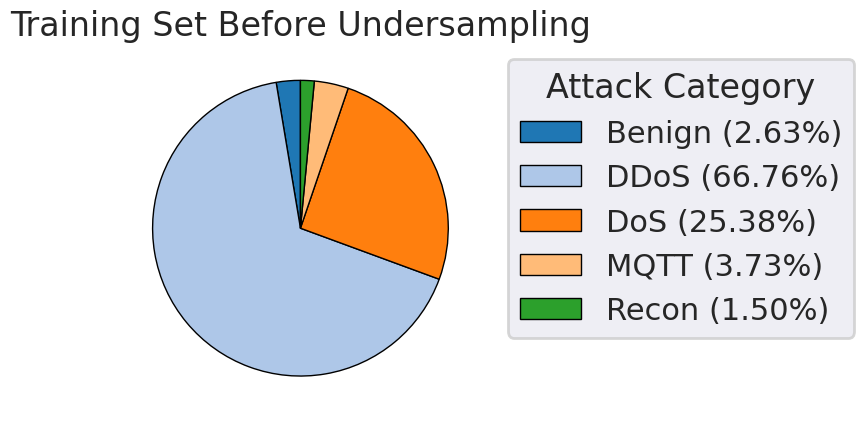

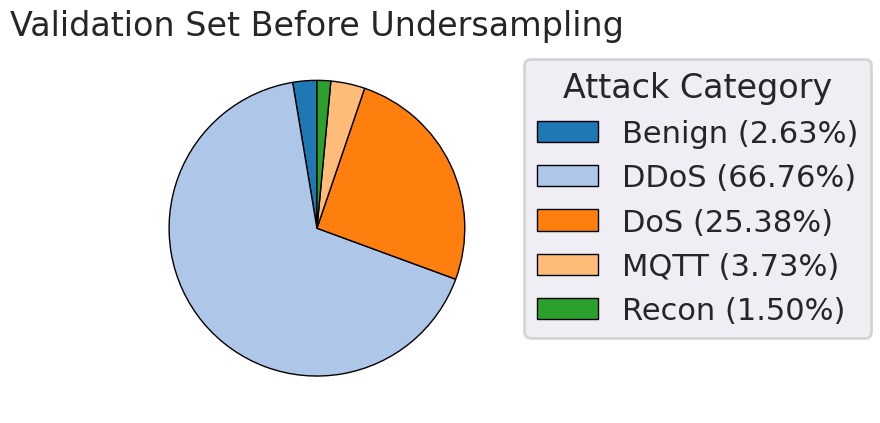

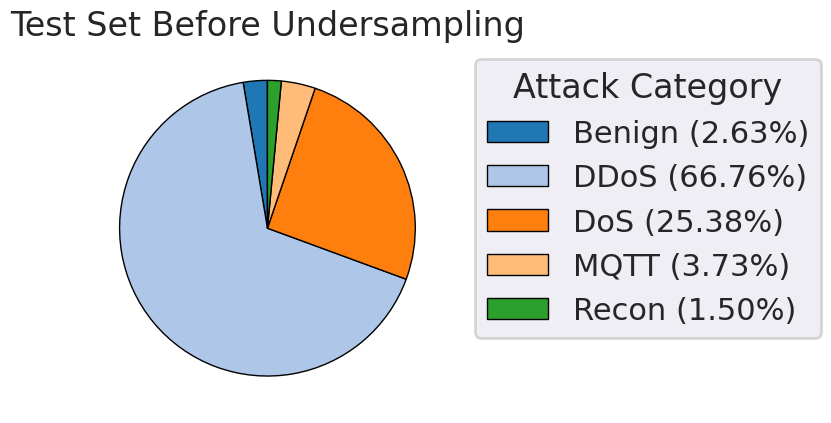

In [15]:
plot_breakdown_pie(
    pl.DataFrame({"Category": y_train}), "Training Set Before Undersampling"
)
plot_breakdown_pie(
    pl.DataFrame({"Category": y_val}), "Validation Set Before Undersampling"
)
plot_breakdown_pie(pl.DataFrame({"Category": y_test}), "Test Set Before Undersampling")

In [16]:
undersample_strategy = {
    "DDoS": 2_500_000,
}
oversample_strategy = {
    "Benign": 1_200_000,
    "MQTT": 800_000,
    "Recon": 600_000,
}

In [17]:
pipeline = Pipeline(
    steps=[
        ("over", SMOTE(sampling_strategy=oversample_strategy, random_state=42)),
        ("under", RandomUnderSampler(sampling_strategy=undersample_strategy)),
    ]
)

In [18]:
X_train, y_train = pipeline.fit_resample(X_train, y_train)

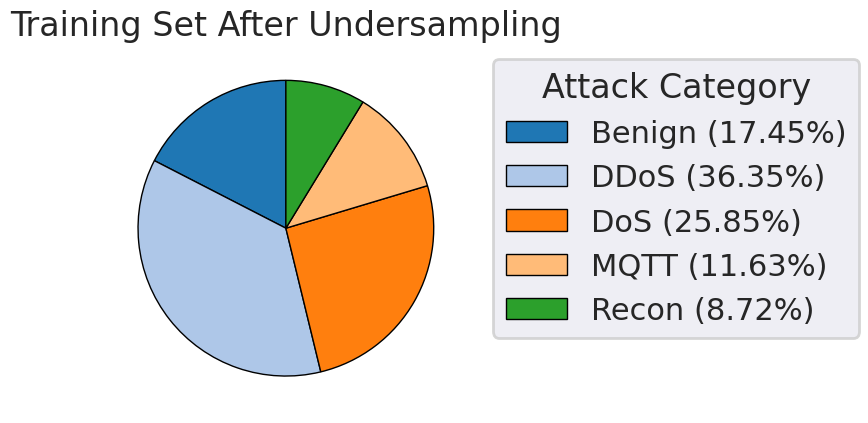

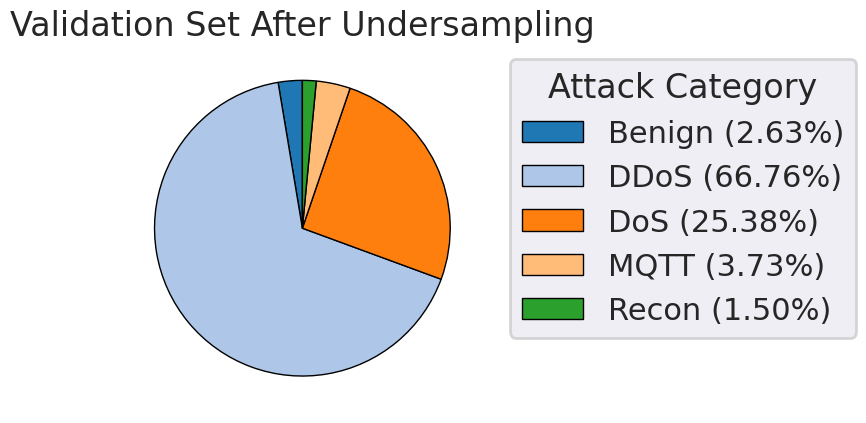

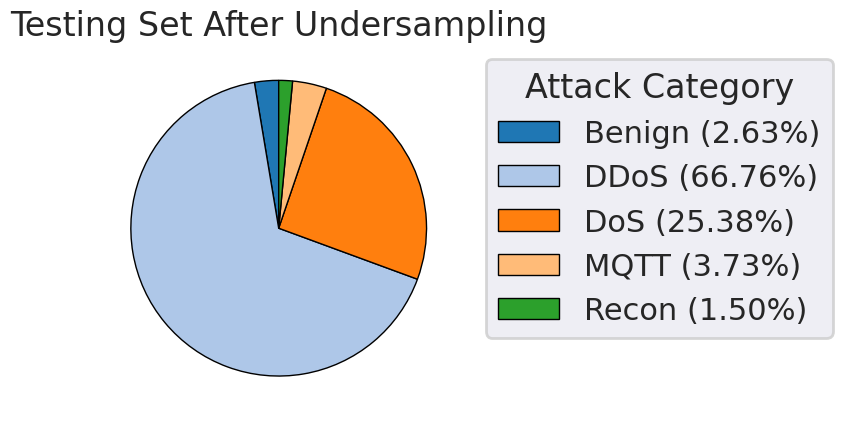

In [19]:
plot_breakdown_pie(
    pl.DataFrame({"Category": y_train}), "Training Set After Undersampling"
)
plot_breakdown_pie(
    pl.DataFrame({"Category": y_val}), "Validation Set After Undersampling"
)
plot_breakdown_pie(
    pl.DataFrame({"Category": y_test}), "Testing Set After Undersampling"
)

### Scaling and Labelling Data

In [20]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_val = encoder.transform(y_val)
y_test = encoder.transform(y_test)

In [21]:
scaler = StandardScaler()
scaler.set_output(transform="pandas")
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [22]:
print(f"Training shape: {X_train.shape[0]} rows")
print(f"Validation shape: {X_val.shape[0]} rows")
print(f"Testing shape: {X_test.shape[0]} rows")

Training shape: 6877763 rows
Validation shape: 875723 rows
Testing shape: 875723 rows


## Model Design

In [23]:
def build_dnn(input_dimensions, output_dimension=5):
    model = Sequential(
        [
            Input(shape=(input_dimensions[1],)),
            Dense(256, activation="gelu", kernel_regularizer=l2(1e-5)),
            BatchNormalization(),
            Dropout(0.3),
            Dense(128, activation="gelu", kernel_regularizer=l2(1e-5)),
            BatchNormalization(),
            Dropout(0.2),
            Dense(64, activation="gelu", kernel_regularizer=l2(1e-5)),
            BatchNormalization(),
            Dropout(0.2),
            Dense(output_dimension, activation="softmax"),
        ]
    )

    optimizer = Adam(learning_rate=3e-4)
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [24]:
model = build_dnn(X_train.shape, 5)
model.summary()

2026-03-14 13:55:18.354316: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        11,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,045 (215.02 KB)

 Trainable params: 54,149 (211.52 KB)

 Non-trainable params: 896 (3.50 KB)

## Model Training

In [25]:
classes = np.unique(y_train)
weights = class_weight.compute_class_weight("balanced", classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

In [26]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=75,
    batch_size=2048,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6),
    ],
    class_weight=class_weights
)

Epoch 1/75
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 52s 15ms/step - accuracy: 0.7398 - loss: 0.3325 - val_accuracy: 0.6892 - val_loss: 0.5675 - learning_rate: 3.0000e-04
Epoch 2/75
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 56s 17ms/step - accuracy: 0.7768 - loss: 0.2825 - val_accuracy: 0.6765 - val_loss: 0.5531 - learning_rate: 3.0000e-04
Epoch 3/75
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - accuracy: 0.7822 - loss: 0.2728 - val_accuracy: 0.7103 - val_loss: 0.5225 - learning_rate: 3.0000e-04
Epoch 4/75
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - accuracy: 0.7844 - loss: 0.2676 - val_accuracy: 0.6888 - val_loss: 0.5306 - learning_rate: 3.0000e-04
Epoch 5/75
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - accuracy: 0.7857 - loss: 0.2647 - val_accuracy: 0.6291 - val_loss: 0.5372 - learning_rate: 3.0000e-04
Epoch 6/75
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 45s 13ms/step - accuracy: 0.7869 - loss: 0.2620 - val_accuracy: 0.6978 - val_loss: 0.5131 - learning_rate: 3.0000e-04
Epoch 7/75
3359/3359 ━━━━━━━━━━━━━━━━━━━

In [27]:
def plot_accuracy_and_loss(history):

    train_loss = history["loss"]
    val_loss = history["val_loss"]
    train_acc = history["accuracy"]
    val_acc = history["val_accuracy"]

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # Accuracy
    ax[0].plot(train_acc, label="Training Accuracy")
    ax[0].plot(val_acc, label="Validation Accuracy")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Accuracy")
    ax[0].legend()

    # Loss
    ax[1].plot(train_loss, label="Training Loss")
    ax[1].plot(val_loss, label="Validation Loss")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Loss")
    ax[1].legend()

    plt.show()

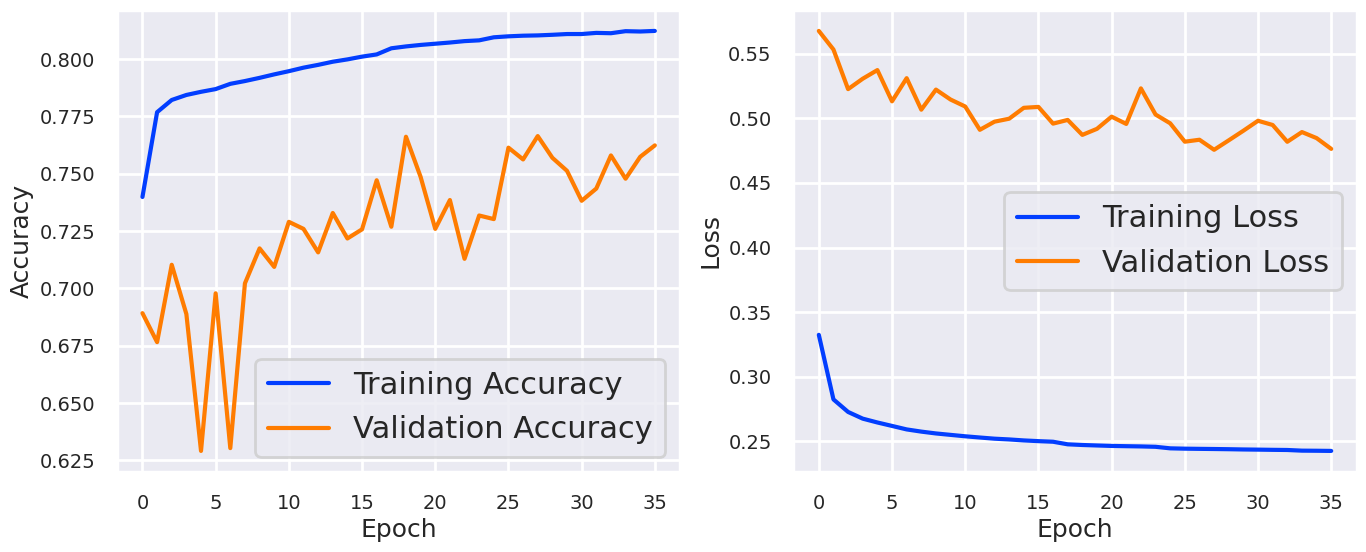

In [28]:
plot_accuracy_and_loss(history.history)

## Saving Variables

In [29]:
if not os.path.exists(ARTIFACT_DIR):
    os.makedirs(ARTIFACT_DIR)
    print(f"Created folder: {ARTIFACT_DIR}")

x_test_path = os.path.join(ARTIFACT_DIR,"X_test.npy")
y_test_path = os.path.join(ARTIFACT_DIR,"y_test.npy")
np.save(x_test_path, X_test)
np.save(y_test_path, y_test)

scaler_path = os.path.join(ARTIFACT_DIR,"scaler.pkl")
encoder_path = os.path.join(ARTIFACT_DIR,"encoder.pkl")
joblib.dump(scaler, scaler_path)
joblib.dump(encoder, encoder_path)

feature_names_path = os.path.join(ARTIFACT_DIR,"feature_names.pkl")
joblib.dump(X_train.columns.to_list(), feature_names_path)

shap_background_path = os.path.join(ARTIFACT_DIR,"shap_background.npy")
background = X_train.sample(1000, random_state=42)
np.save(shap_background_path, background.values)

print("Saved: X_test.npy, y_test.npy, scaler.pkl, encoder.pkl, feature_names.pkl, shap_background.npy")

Saved: X_test.npy, y_test.npy, scaler.pkl, encoder.pkl, feature_names.pkl, shap_background.npy


In [30]:
if not os.path.exists(MODEL_DIR):
    os.makedirs(MODEL_DIR)
    print(f"Created folder: {MODEL_DIR}")

model_path = os.path.join(MODEL_DIR, "model.keras")
model.save(model_path)
history_path = os.path.join(MODEL_DIR, "history.csv")
hist_df = pd.DataFrame(history.history)
hist_df.to_csv(history_path, index = False)

print("Saved: model.keras, history.keras")

Saved: model.keras, history.keras
